# MCMC to find params of a damped harmonic oscillator

We observe noisy position measurements from a damped spring:

    x(t) = A * exp(-gamma * t) * cos(omega * t + phi)

True parameters are known (we generate the data), and we use MCMC
(Metropolis-Hastings) to recover the posterior over theta = {A, gamma, omega, phi}.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import corner

In [15]:
# ── 1. True parameters and data generation ────────────────────────────────────

TRUE_PARAMS = {
    "A":     2.0,   # amplitude
    "gamma": 0.3,   # damping rate
    "omega": 2.0,   # angular frequency
    "phi":   0.5,   # phase offset
}
SIGMA_NOISE = 0.3   # observation noise std

np.random.seed(42)
t_obs = np.linspace(0, 10, 40)  # 40 observation times


def model(t, A, gamma, omega, phi):
    return A * np.exp(-gamma * t) * np.cos(omega * t + phi)


y_true = model(t_obs, **TRUE_PARAMS)
y_obs  = y_true + np.random.normal(0, SIGMA_NOISE, size=len(t_obs))

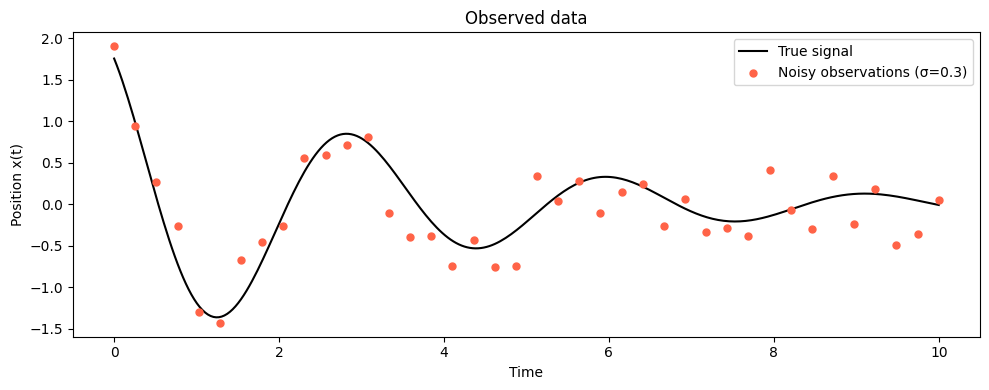

In [16]:
t_fine = np.linspace(0, 10, 300)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_fine, model(t_fine, **TRUE_PARAMS), "k-", lw=1.5, label="True signal")
ax.scatter(t_obs, y_obs, color="tomato", s=25, zorder=5, label=f"Noisy observations (σ={SIGMA_NOISE})")
ax.set_xlabel("Time")
ax.set_ylabel("Position x(t)")
ax.set_title("Observed data")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# ── 2. Bayesian components ─────────────────────────────────────────────────────

def log_likelihood(params, t, y, sigma):
    A, gamma, omega, phi = params
    y_pred = model(t, A, gamma, omega, phi)
    residuals = y - y_pred
    return -0.5 * np.sum((residuals / sigma) ** 2)


def log_prior(params):
    A, gamma, omega, phi = params
    # Uniform priors with physically sensible bounds
    if (0.1 < A < 10.0 and
        0.01 < gamma < 2.0 and
        0.1 < omega < 10.0 and
        -np.pi < phi < np.pi):
        return 0.0   # log(1) — flat within bounds
    return -np.inf   # log(0) — outside bounds


def log_posterior(params, t, y, sigma):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, t, y, sigma)

In [ ]:
# ── 3. Metropolis-Hastings MCMC (adaptive proposal) ──────────────────────────
#
# Uses the Adaptive Metropolis algorithm (Haario et al. 2001):
#   - After `adapt_start` steps, estimate the empirical covariance of the chain
#     and use it (scaled by 2.38²/d) as the proposal covariance.
#   - This automatically tunes step sizes and handles parameter correlations
#     (critical here because omega and phi trade off via omega*t + phi).

def run_mcmc(log_post_fn, initial_params, n_steps=200_000, proposal_std=None, adapt_start=2_000, adapt_interval=500):
    n_params = len(initial_params)
    if proposal_std is None:
        proposal_std = np.array([0.1, 0.04, 0.1, 0.1])

    # Roberts & Rosenthal (2001) optimal scaling for Gaussian targets
    scale = (2.38 ** 2) / n_params
    cov = np.diag(proposal_std ** 2)

    chain = np.zeros((n_steps, n_params))
    current = np.array(initial_params, dtype=float)
    log_p_current = log_post_fn(current)
    accepted = 0

    for i in range(n_steps):
        proposal = current + np.random.multivariate_normal(np.zeros(n_params), cov)
        log_p_proposal = log_post_fn(proposal)

        if np.log(np.random.uniform()) < log_p_proposal - log_p_current:
            current = proposal
            log_p_current = log_p_proposal
            accepted += 1

        chain[i] = current

        # Periodically update proposal covariance from empirical chain covariance
        if i >= adapt_start and i % adapt_interval == 0:
            emp_cov = np.cov(chain[:i].T)
            if np.all(np.isfinite(emp_cov)):
                cov = scale * emp_cov + scale * 1e-8 * np.eye(n_params)

    print(f"Acceptance rate: {accepted / n_steps:.2%}")
    return chain

In [19]:
# Initial guess — deliberately offset from truth
initial = [1.5, 0.2, 1.8, 0.3]

print("Running MCMC (200k steps, adaptive proposal)...")
chain = run_mcmc(
    lambda p: log_posterior(p, t_obs, y_obs, SIGMA_NOISE),
    initial_params=initial,
    n_steps=200_000,
)

Running MCMC (200k steps, adaptive proposal)...
Acceptance rate: 29.24%


In [ ]:
# Discard burn-in, then thin to reduce autocorrelation
burn_in = 20_000
thin = 5
samples = chain[burn_in::thin]

param_names = ["A", "γ", "ω", "φ"]
true_values = list(TRUE_PARAMS.values())

print(f"Posterior summary  ({len(samples):,} samples after burn-in + thinning):")
print(f"{'Param':<8} {'True':>8} {'Mean':>8} {'Std':>8} {'2.5%':>8} {'97.5%':>8}")
for name, true, col in zip(param_names, true_values, samples.T):
    print(f"{name:<8} {true:>8.3f} {col.mean():>8.3f} {col.std():>8.3f} "
          f"{np.percentile(col, 2.5):>8.3f} {np.percentile(col, 97.5):>8.3f}")

Posterior summary  (36,000 samples after burn-in + thinning):
Param        True     Mean      Std     2.5%    97.5%
A           2.000    1.901    0.235    1.465    2.386
γ           0.300    0.335    0.064    0.227    0.475
ω           2.000    2.133    0.064    2.007    2.258
φ           0.500    0.324    0.133    0.054    0.572


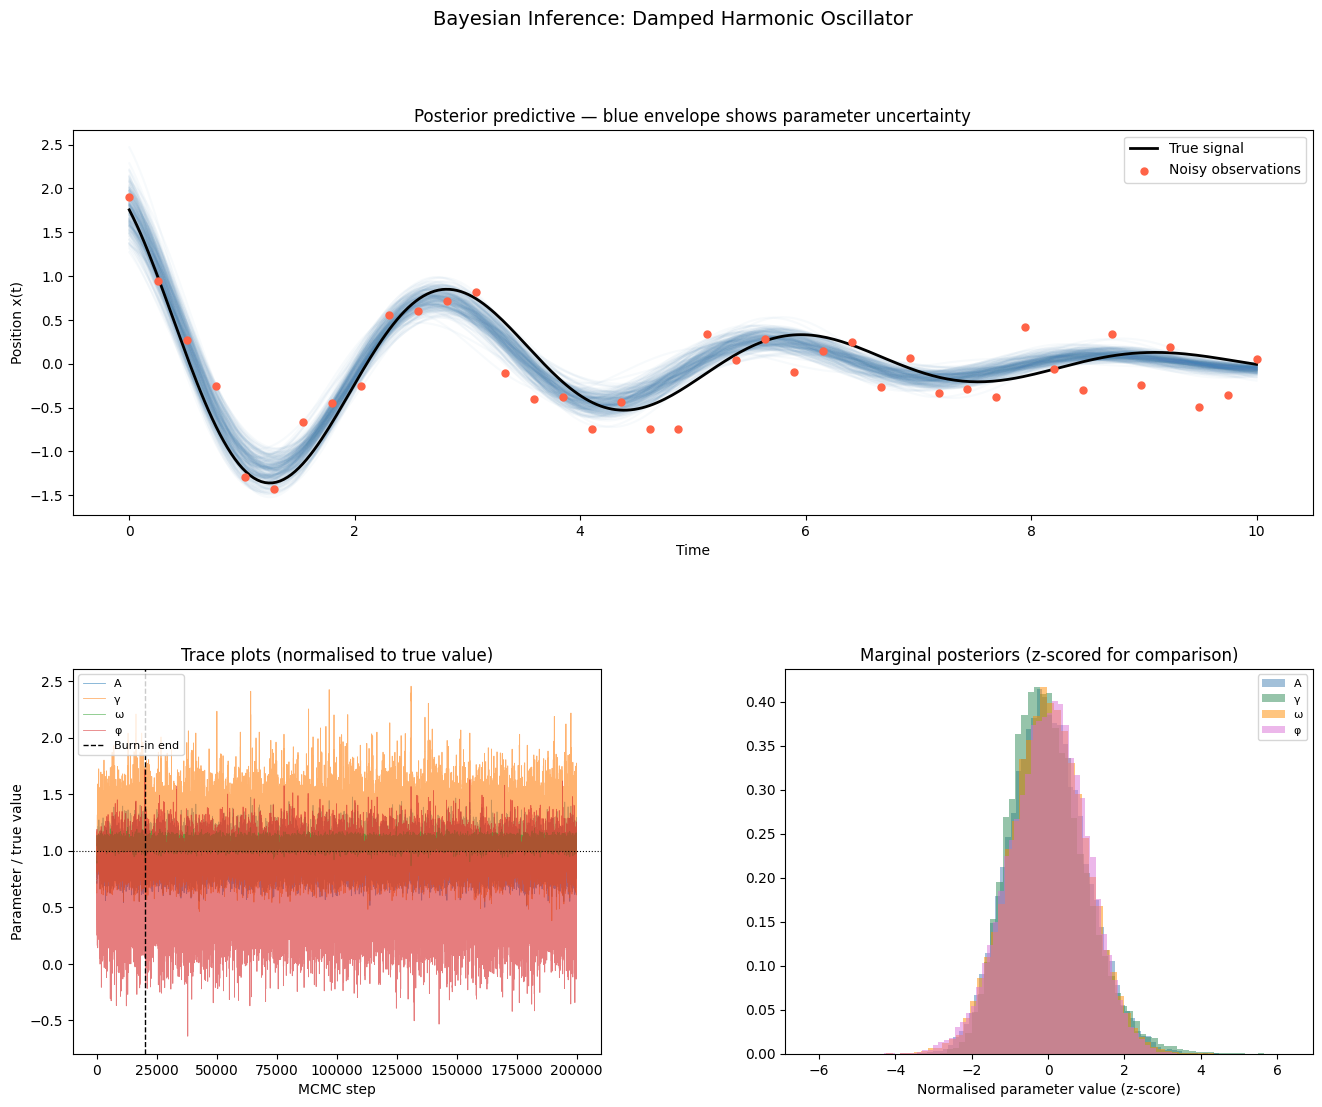

In [21]:
# ── 4. Plots: posterior predictive, trace, marginal histograms ────────────────

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Bayesian Inference: Damped Harmonic Oscillator", fontsize=14, y=0.98)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 4a. Data + posterior predictive ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
t_fine = np.linspace(0, 10, 300)

for sample in samples[np.random.choice(len(samples), 200, replace=False)]:
    ax1.plot(t_fine, model(t_fine, *sample), color="steelblue", alpha=0.04)

ax1.plot(t_fine, model(t_fine, **TRUE_PARAMS), "k-", lw=2, label="True signal")
ax1.scatter(t_obs, y_obs, color="tomato", s=25, zorder=5, label="Noisy observations")
ax1.set_xlabel("Time")
ax1.set_ylabel("Position x(t)")
ax1.set_title("Posterior predictive — blue envelope shows parameter uncertainty")
ax1.legend()

# ── 4b. Trace plots ───────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
for i, (name, true) in enumerate(zip(param_names, true_values)):
    ax2.plot(chain[:, i] / true_values[i], alpha=0.6, label=name, lw=0.6)
ax2.axvline(burn_in, color="k", linestyle="--", lw=1, label="Burn-in end")
ax2.axhline(1.0, color="k", linestyle=":", lw=0.8)
ax2.set_xlabel("MCMC step")
ax2.set_ylabel("Parameter / true value")
ax2.set_title("Trace plots (normalised to true value)")
ax2.legend(fontsize=8)

# ── 4c. Marginal posteriors ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
colours = ["steelblue", "seagreen", "darkorange", "orchid"]
for i, (name, true, col, c) in enumerate(zip(param_names, true_values, samples.T, colours)):
    normed = (col - col.mean()) / col.std()
    ax3.hist(normed, bins=60, density=True, alpha=0.5, color=c, label=name)
ax3.set_xlabel("Normalised parameter value (z-score)")
ax3.set_title("Marginal posteriors (z-scored for comparison)")
ax3.legend(fontsize=8)

plt.show()

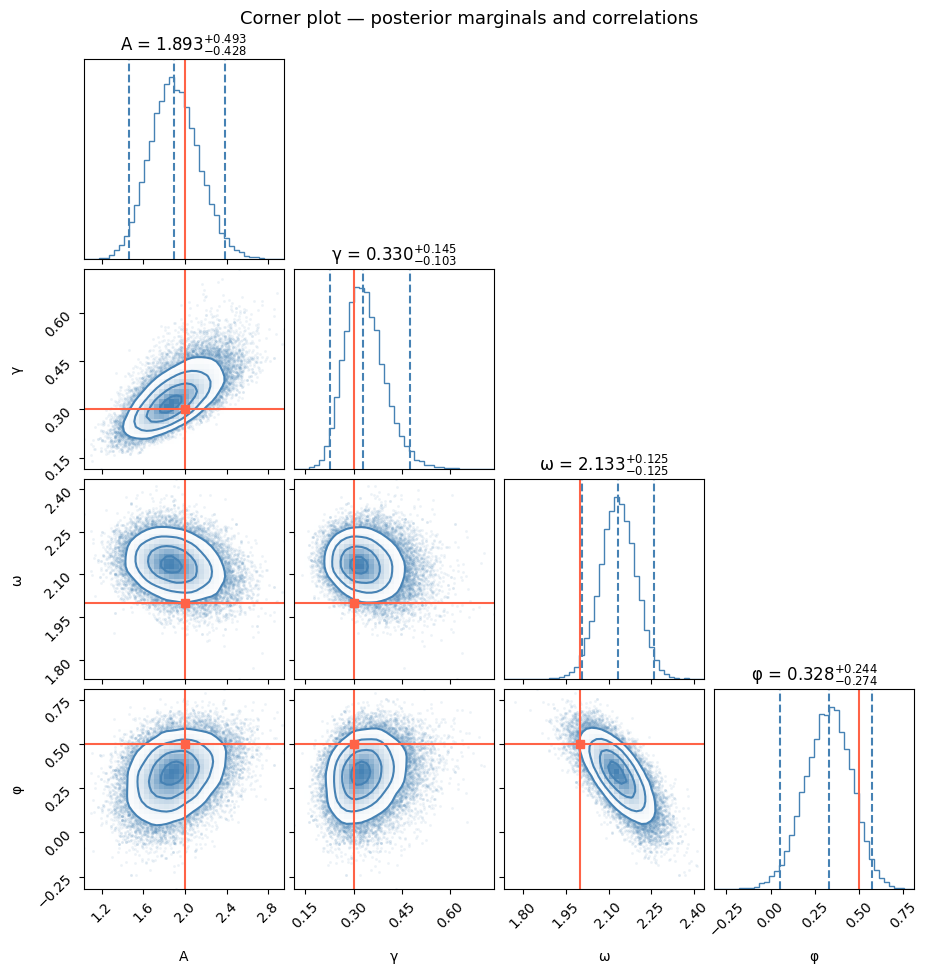

In [22]:
# ── 5. Corner plot — parameter correlations ───────────────────────────────────

fig_corner = corner.corner(
    samples,
    labels=param_names,
    truths=true_values,
    truth_color="tomato",
    color="steelblue",
    bins=40,
    smooth=1.0,
    title_fmt=".3f",
    show_titles=True,
    quantiles=[0.025, 0.5, 0.975],
)
fig_corner.suptitle("Corner plot — posterior marginals and correlations", y=1.01, fontsize=13)
plt.show()